---
date: "2026-07-14"
date-modified: last-modified
format:
  html:
    toc: true
---

# Limits of Measurable Functions and Almost Everywhere Convergence

## 1\. Pointwise Limits of Measurable Functions

One of the most fundamental advantages of the Lebesgue integral and [measurable functions](measurable-functions.ipynb) over the Riemann integral is their robustness under limits. While the [pointwise limit](function-spaces.ipynb#pointwise-convergence-the-weak-form) of a sequence of Riemann-integrable functions can fail to be Riemann-integrable, the pointwise limit of a sequence of measurable functions is always measurable.

Let $(X, \mathcal{M})$ be a [measurable space](measure.ipynb), where $X$ is a set and $\mathcal{M}$ is a [$\sigma$-algebra](sigma-algebra.ipynb) on $X$.

**Proposition 1 (Pointwise Limit of Measurable Functions)**
Let $(f_n)_{n=1}^\infty$ be a sequence of extended real-valued [measurable functions](measurable-functions.ipynb), $f_n: X \to [-\infty, \infty]$. If $(f_n)_{n=1}^\infty$ converges pointwise to a function $f: X \to [-\infty, \infty]$ on $X$ (that is, $\lim_{n \to \infty} f_n(x) = f(x)$ for all $x \in X$), then the limit function $f$ is measurable.

::: {.callout-tip collapse="true"}
## Proof of Proposition 1

To prove that $f$ is a measurable function, we must show that for any real number $c \in \mathbb{R}$, the preimage level set $f^{-1}((-\infty, c]) = \{x \in X \mid f(x) \leq c\}$ belongs to the $\sigma$-algebra $\mathcal{M}$.

**Step 1: Expressing the level set via strictly larger thresholds for large $n$**
Observe that if $f_n(x) \to f(x)$ as $n \to \infty$, then $f(x) \leq c$ if and only if for every $\varepsilon > 0$, there exists some index $N \in \mathbb{N}$ such that for all $n \geq N$, we have $f_n(x) < c + \varepsilon$.

To see why, notice that if $f(x) \leq c$, the definition of convergence implies that $f_n(x)$ eventually lies within any $\varepsilon$-neighborhood of $f(x)$, so for large $n$, $f_n(x) < f(x) + \varepsilon \leq c + \varepsilon$. Conversely, if for every $\varepsilon > 0$, $f_n(x) < c + \varepsilon$ for all sufficiently large $n$, taking the limit as $n \to \infty$ yields $f(x) \leq c + \varepsilon$ for all $\varepsilon > 0$, which forces $f(x) \leq c$.

**Step 2: Rewriting using countable set operations over integer thresholds**
Rather than checking all $\varepsilon > 0$, it suffices by the Archimedean property to check $\varepsilon = \frac{1}{k}$ for each positive integer $k \in \mathbb{N}$. We can therefore express the set $\{x \in X \mid f(x) \leq c\}$ precisely as:
$$
\begin{aligned}
\{x \in X \mid f(x) \leq c\} &= \left\{x \in X \;\middle|\; \forall k \in \mathbb{N}, \; \exists N \in \mathbb{N} \text{ s.t. } \forall n \geq N, \; f_n(x) < c + \frac{1}{k}\right\} \\
&= \bigcap_{k=1}^\infty \bigcup_{N=1}^\infty \bigcap_{n=N}^\infty \left\{x \in X \;\middle|\; f_n(x) < c + \frac{1}{k}\right\}
\end{aligned}
$$

**Step 3: Concluding measurability using $\sigma$-algebra closure properties**
By hypothesis, each $f_n$ is a measurable function. Therefore, by [Proposition 1 of measurable functions](measurable-functions.ipynb#formal-definition-and-equivalent-characterizations), for any given integers $k, n \in \mathbb{N}$, the set:
$$
E_{n, k} = \left\{x \in X \;\middle|\; f_n(x) < c + \frac{1}{k}\right\}
$$
is an element of $\mathcal{M}$.

Because any $\sigma$-algebra $\mathcal{M}$ is closed under countable intersections and countable unions, the set:
$$
\{x \in X \mid f(x) \leq c\} = \bigcap_{k=1}^\infty \bigcup_{N=1}^\infty \bigcap_{n=N}^\infty E_{n, k}
$$
must belong to $\mathcal{M}$. Hence, $f$ is measurable. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Countable Operations and Pointwise Limits
Why does taking a limit preserve measurability? The key lies in the fact that the real line $\mathbb{R}$ has a dense countable subset ($\mathbb{Q}$) and the definition of a limit involves quantifiers ("for all $\varepsilon > 0$, there exists $N$..."). By replacing "for all $\varepsilon > 0$" with "for all $k \in \mathbb{N}$ ($\varepsilon = 1/k$)", logical universal quantifiers ($\forall$) translate into countable intersections ($\bigcap$), while existential quantifiers ($\exists$) translate into countable unions ($\bigcup$). Since $\sigma$-algebras are specifically designed to be closed under countable set operations, measurability is perfectly preserved under pointwise limits.
:::

<!-- CELL BREAK -->


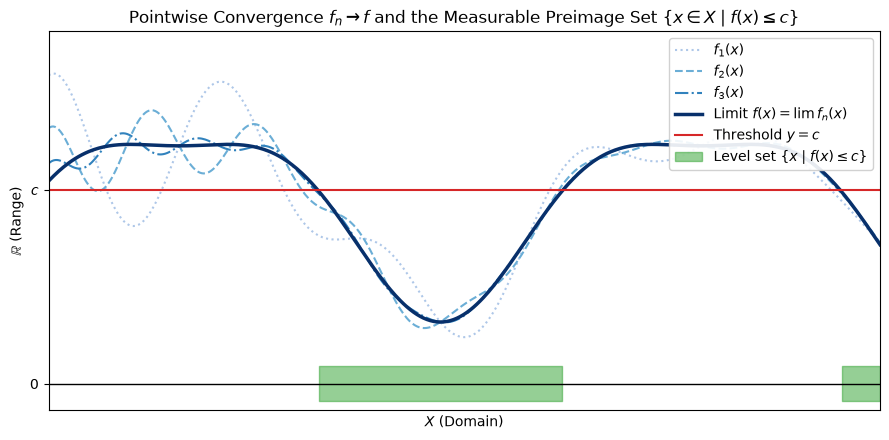

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate domain x values
x = np.linspace(0, 10, 500)

# Define target limit function f(x) and sequence f_n(x) approaching it
f = np.sin(x) + 0.3 * np.cos(2 * x) + 2
f_1 = f + 1.2 * np.exp(-x / 4) * np.cos(3 * x)
f_2 = f + 0.6 * np.exp(-x / 3) * np.cos(5 * x)
f_3 = f + 0.2 * np.exp(-x / 2) * np.cos(7 * x)

c = 2.2  # Threshold value c

plt.figure(figsize=(9, 4.5))
plt.plot(x, f_1, color='#aec7e8', linestyle=':', label=r'$f_1(x)$')
plt.plot(x, f_2, color='#6baed6', linestyle='--', label=r'$f_2(x)$')
plt.plot(x, f_3, color='#3182bd', linestyle='-.', label=r'$f_3(x)$')
plt.plot(x, f, color='#08306b', linewidth=2.5, label=r'Limit $f(x) = \lim f_n(x)$')

plt.axhline(y=c, color='#d62728', linestyle='-', linewidth=1.5, label=r'Threshold $y = c$')

# Highlight the level set {x | f(x) <= c} on the x-axis
mask = f <= c
plt.fill_between(x, -0.2, 0.2, where=mask, color='#2ca02c', alpha=0.5, label=r'Level set $\{x \mid f(x) \leq c\}$')
plt.axhline(y=0, color='black', linewidth=1)

plt.xlim(0, 10)
plt.ylim(-0.3, 4)
plt.yticks([0, c], ['0', r'$c$'])
plt.xticks([])
plt.legend(loc='upper right', framealpha=0.9)
plt.title(r'Pointwise Convergence $f_n \to f$ and the Measurable Preimage Set $\{x \in X \mid f(x) \leq c\}$')
plt.xlabel(r'$X$ (Domain)')
plt.ylabel(r'$\mathbb{R}$ (Range)')
plt.tight_layout()
plt.show()



## 2\. Convergence and Equality Almost Everywhere

In measure theory, behavior that occurs on a set of [measure zero](measure.ipynb) is often negligible when computing integrals. Consequently, we weaken our requirement of pointwise convergence everywhere to convergence everywhere *except* possibly on a null set.

Let $(X, \mathcal{M}, \mu)$ be a [measure space](measure.ipynb).

**Definition 1 (Convergence Almost Everywhere)**
Let $(f_n)_{n=1}^\infty$ be a sequence of functions defined on $X$, and let $f: X \to [-\infty, \infty]$. We say that $(f_n)_{n=1}^\infty$ **converges almost everywhere** (or $\mu$-almost everywhere) to $f$, written:
$$
f_n \xrightarrow{\text{a.e. } (\mu)} f \quad \text{as } n \to \infty
$$
if the set of points where convergence fails has [measure zero](measure.ipynb), that is:
$$
\mu\left(\left\{x \in X \;\middle|\; f_n(x) \not\to f(x)\right\}\right) = 0
$$
[Note: In this general definition, we do not strictly assume beforehand that the functions $f_n$ and $f$ are measurable. However, the set where convergence fails is assumed to be measurable so that its measure $\mu$ is well-defined.]{.aside}

**Definition 2 (Equality Almost Everywhere)**
Two functions $f, g: X \to [-\infty, \infty]$ are said to be **equal almost everywhere** (written $f = g \text{ a.e. } (\mu)$) if the set of points where they differ has [measure zero](measure.ipynb):
$$
\mu\left(\left\{x \in X \;\middle|\; f(x) \neq g(x)\right\}\right) = 0
$$

<!-- CELL BREAK -->

## 3\. Measurability in Complete Measure Spaces

When dealing with almost everywhere relationships, technical issues can arise if the underlying [measure space](measure.ipynb) contains subsets of null sets that are not in the [$\sigma$-algebra](sigma-algebra.ipynb) $\mathcal{M}$. Working in a **[complete measure space](measure-properties-and-completion.ipynb)** eliminates these pathologies.

> **Reminder on Complete Measure Spaces:**
> Recall that a [measure space](measure.ipynb) $(X, \mathcal{M}, \mu)$ is called a **[complete measure space](measure-properties-and-completion.ipynb)** if whenever $E \in \mathcal{M}$ satisfies $\mu(E) = 0$, every subset $D \subseteq E$ is also measurable (i.e., $D \in \mathcal{M}$, and consequently $\mu(D) = 0$).

**Proposition 2 (Measurability Under Almost Everywhere Relationships)**
Let $(X, \mathcal{M}, \mu)$ be a [complete measure space](measure-properties-and-completion.ipynb). Then:

1. **Part (a) — Almost Everywhere Equality:** If $f: X \to [-\infty, \infty]$ is [measurable](measurable-functions.ipynb) and $f = g \text{ a.e. } (\mu)$, then $g: X \to [-\infty, \infty]$ is also [measurable](measurable-functions.ipynb).
2. **Part (b) — Almost Everywhere Limits:** If $(f_n)_{n=1}^\infty$ is a sequence of [measurable functions](measurable-functions.ipynb) such that $f_n \xrightarrow{\text{a.e. } (\mu)} f$, then $f: X \to [-\infty, \infty]$ is [measurable](measurable-functions.ipynb).

::: {.callout-tip collapse="true"}
## Proof of Proposition 2

**Proof of Part (a):**
Let $c \in \mathbb{R}$ be an arbitrary real number. Define the level sets for $g$ and $f$ as:
$$
A = \{x \in X \mid g(x) \leq c\} \quad \text{and} \quad B = \{x \in X \mid f(x) \leq c\}
$$
Because $f$ is [measurable](measurable-functions.ipynb), we know that $B \in \mathcal{M}$. We must prove that $A \in \mathcal{M}$.

**Step 1: Relating set differences to the set of divergence between $f$ and $g$**
Examine the set differences $A \setminus B$ and $B \setminus A$:

* If $x \in A \setminus B$, then $g(x) \leq c$ and $f(x) > c$, which implies $f(x) \neq g(x)$.
* If $x \in B \setminus A$, then $f(x) \leq c$ and $g(x) > c$, which also implies $f(x) \neq g(x)$.

Therefore, both set differences are contained inside the set where $f$ and $g$ disagree:
$$
(A \setminus B) \subseteq \{x \in X \mid f(x) \neq g(x)\} \quad \text{and} \quad (B \setminus A) \subseteq \{x \in X \mid f(x) \neq g(x)\}
$$

**Step 2: Invoking completeness of the measure space**
By hypothesis, $f = g \text{ a.e. } (\mu)$, which means $\mu(\{x \in X \mid f(x) \neq g(x)\}) = 0$.
Since $(X, \mathcal{M}, \mu)$ is a [complete measure space](measure-properties-and-completion.ipynb), any subset of a set of measure zero is measurable and has measure zero. Thus:
$$
A \setminus B \in \mathcal{M} \quad \text{and} \quad B \setminus A \in \mathcal{M}
$$

**Step 3: Decomposing $A$ into measurable components**
Using standard set decomposition identities, we express $A$ as:
$$
A = (A \setminus B) \cup \left(B \setminus (B \setminus A)\right)
$$
Since $B \in \mathcal{M}$ and $(B \setminus A) \in \mathcal{M}$, the set difference $B \setminus (B \setminus A)$ belongs to $\mathcal{M}$ (because [$\sigma$-algebras](sigma-algebra.ipynb) are closed under relative complementation).
Then, as the union of two measurable sets $(A \setminus B)$ and $B \setminus (B \setminus A)$, we conclude that $A \in \mathcal{M}$. Since $A = \{x \in X \mid g(x) \leq c\} \in \mathcal{M}$ for all $c \in \mathbb{R}$, $g$ is [measurable](measurable-functions.ipynb). $\blacksquare$

---

**Proof of Part (b):**
Let $E = \{x \in X \mid f_n(x) \to f(x)\}$ denote the set of points where the sequence $(f_n)_{n=1}^\infty$ converges to $f$.
By definition of almost everywhere convergence, its complement $N = X \setminus E = \{x \in X \mid f_n(x) \not\to f(x)\}$ has [measure zero](measure.ipynb), so $\mu(N) = 0$.

**Step 1: Constructing a modified sequence that converges pointwise everywhere**
Let $\mathbb{I}_E: X \to \{0, 1\}$ denote the [characteristic function]() (indicator function) of $E$. Define a modified sequence of functions $\tilde{f}_n: X \to [-\infty, \infty]$ by:
$$
\tilde{f}_n(x) = \begin{cases}
f_n(x) & \text{if } x \in E \\
0 & \text{if } x \in N
\end{cases}
$$
Because $(X, \mathcal{M}, \mu)$ is [complete](measure-properties-and-completion.ipynb) and $\mu(N) = 0$, the null set satisfies $N \in \mathcal{M}$, which implies $E = X \setminus N \in \mathcal{M}$. Thus, the indicator $\mathbb{I}_E$ is a [measurable function](measurable-functions.ipynb). Since each $\tilde{f}_n = f_n \cdot \mathbb{I}_E$ is the product of measurable functions, each $\tilde{f}_n$ is [measurable](measurable-functions.ipynb).

**Step 2: Taking the pointwise limit everywhere on $X$**
Define $h: X \to [-\infty, \infty]$ as the pointwise limit of $\tilde{f}_n$:
$$
h(x) = \lim_{n \to \infty} \tilde{f}_n(x) = \begin{cases}
f(x) & \text{if } x \in E \\
0 & \text{if } x \in N
\end{cases}
$$
Because the sequence $(\tilde{f}_n)_{n=1}^\infty$ converges **pointwise everywhere** on $X$ to $h$, and each $\tilde{f}_n$ is measurable, the limit function $h$ is [measurable](measurable-functions.ipynb) by **Proposition 1** proved above.

**Step 3: Concluding measurability of $f$ using Part (a)**
Observe that $f(x) = h(x)$ for all $x \in E$. Consequently:
$$
\{x \in X \mid f(x) \neq h(x)\} \subseteq N
$$
Since $\mu(N) = 0$, we have $f = h \text{ a.e. } (\mu)$.
Because $(X, \mathcal{M}, \mu)$ is complete, $h$ is measurable, and $f = h \text{ a.e. } (\mu)$, Part (a) immediately implies that $f$ is [measurable](measurable-functions.ipynb). $\blacksquare$
:::

::: {.callout-warning}
## Completeness is Essential: Incomplete Measure Spaces Can Fail
If the measure space $(X, \mathcal{M}, \mu)$ is **not complete**, Proposition 2 generally fails! 

For example, consider the Borel [$\sigma$-algebra](sigma-algebra.ipynb) $\mathcal{B}(\mathbb{R})$ on $\mathbb{R}$ with the standard [Lebesgue measure](Lebesgue-measure.ipynb) restricted to Borel sets. There exist Cantor-type sets $C \in \mathcal{B}(\mathbb{R})$ with $\mu(C) = 0$ that contain non-Borel subsets $V \subset C$ where $V \notin \mathcal{B}(\mathbb{R})$. If we define $f(x) = 0$ everywhere on $\mathbb{R}$ and $g(x) = \mathbb{I}_V(x)$ (the indicator of $V$), then $f$ is Borel measurable and $f = g \text{ a.e. } (\mu)$ because $\{x \mid f(x) \neq g(x)\} = V \subset C$. However, $g$ is **not** Borel measurable because $g^{-1}(\{1\}) = V \notin \mathcal{B}(\mathbb{R})$. This pathology is precisely why standard measure theory works with the **completion** of the Borel $\sigma$-algebra—the [Lebesgue $\sigma$-algebra](sigma-algebra-of-measurable-sets.ipynb).
:::

<!-- CELL BREAK -->

## 4\. Supremum, Infimum, and Limit Superior/Inferior of Measurable Functions

In addition to pointwise limits, measure theory guarantees that taking the supremum, infimum, limit superior, or limit inferior of a countable sequence of [measurable functions](measurable-functions.ipynb) always yields a measurable function. This property is essential when constructing envelopes of functions or studying sequences that may not converge pointwise everywhere.

Let $(X, \mathcal{M})$ be a [measurable space](measure.ipynb), where $X$ is a set and $\mathcal{M}$ is a [$\sigma$-algebra](sigma-algebra.ipynb) on $X$.

**Proposition 3 (Supremum and Infimum of Measurable Functions)**
Let $(f_n)_{n=1}^\infty$ be a sequence of extended real-valued [measurable functions](measurable-functions.ipynb), $f_n: X \to [-\infty, \infty]$. Then the functions defined pointwise by:
$$
g(x) = \sup_{n \in \mathbb{N}} f_n(x) \quad \text{and} \quad h(x) = \inf_{n \in \mathbb{N}} f_n(x)
$$
are both [measurable functions](measurable-functions.ipynb) from $X$ to $[-\infty, \infty]$. Furthermore, $\limsup_{n \to \infty} f_n$ and $\liminf_{n \to \infty} f_n$ are also measurable.

::: {.callout-tip collapse="true"}
## Proof of Proposition 3

To prove that a function is measurable, it suffices to show that its preimage level sets belong to the $\sigma$-algebra $\mathcal{M}$ for every $c \in \mathbb{R}$.

**Step 1: Measurability of the supremum ($\sup f_n$)**
Observe that for any $x \in X$, the supremum of the sequence $\sup_{n \in \mathbb{N}} f_n(x)$ is less than or equal to a threshold $c \in \mathbb{R}$ if and only if *every* term in the sequence satisfies $f_n(x) \leq c$. Therefore, we can express the level set of $g = \sup_{n \in \mathbb{N}} f_n$ exactly as a countable intersection of level sets:
$$
\{x \in X \mid g(x) \leq c\} = \left\{x \in X \;\middle|\; \sup_{n \in \mathbb{N}} f_n(x) \leq c\right\} = \bigcap_{n=1}^\infty \{x \in X \mid f_n(x) \leq c\}
$$
Because each $f_n$ is a [measurable function](measurable-functions.ipynb), each set $E_n = \{x \in X \mid f_n(x) \leq c\}$ is an element of $\mathcal{M}$. Since any [$\sigma$-algebra](sigma-algebra.ipynb) $\mathcal{M}$ is closed under countable intersections, their intersection $\bigcap_{n=1}^\infty E_n$ belongs to $\mathcal{M}$. Hence, $g = \sup_{n \in \mathbb{N}} f_n$ is measurable.

**Step 2: Measurability of the infimum ($\inf f_n$)**
Similarly, for the infimum $h = \inf_{n \in \mathbb{N}} f_n$, observe that $\inf_{n \in \mathbb{N}} f_n(x)$ is greater than or equal to $c$ if and only if $f_n(x) \geq c$ for *all* $n \in \mathbb{N}$. Thus:
$$
\{x \in X \mid h(x) \geq c\} = \left\{x \in X \;\middle|\; \inf_{n \in \mathbb{N}} f_n(x) \geq c\right\} = \bigcap_{n=1}^\infty \{x \in X \mid f_n(x) \geq c\}
$$
By [equivalent characterizations of measurability](measurable-functions.ipynb#formal-definition-and-equivalent-characterizations), each level set $\{x \in X \mid f_n(x) \geq c\}$ is in $\mathcal{M}$. Since $\mathcal{M}$ is closed under countable intersections, $\{x \in X \mid h(x) \geq c\} \in \mathcal{M}$, proving that $h = \inf_{n \in \mathbb{N}} f_n$ is measurable.

*(Alternatively, one can use the identity $\inf_{n \in \mathbb{N}} f_n = -\sup_{n \in \mathbb{N}}(-f_n)$ along with the fact that scalar multiples and suprema of measurable functions are measurable.)*

**Step 3: Measurability of $\limsup$ and $\liminf$**
Recall the formal definitions of the limit superior and limit inferior of a sequence of functions:
$$
\begin{aligned}
\limsup_{n \to \infty} f_n(x) &= \inf_{k \geq 1} \left( \sup_{n \geq k} f_n(x) \right) \\
\liminf_{n \to \infty} f_n(x) &= \sup_{k \geq 1} \left( \inf_{n \geq k} f_n(x) \right)
\end{aligned}
$$
For each fixed integer $k \geq 1$, define $u_k(x) = \sup_{n \geq k} f_n(x)$. By **Step 1**, each $u_k$ is a measurable function. Then, taking the infimum over all $k \geq 1$, the function $\inf_{k \geq 1} u_k = \limsup_{n \to \infty} f_n$ is measurable by **Step 2**. 

By the exact same reasoning applied to $\liminf_{n \to \infty} f_n = \sup_{k \geq 1} (\inf_{n \geq k} f_n)$, the limit inferior is also measurable. $\blacksquare$
:::

::: {.callout-note}
## Connection to Proposition 1 (Pointwise Convergence)
Notice that Proposition 3 provides an alternative, immediate proof of **Proposition 1**! If a sequence $(f_n)_{n=1}^\infty$ of measurable functions converges pointwise to $f(x)$ for all $x \in X$, then by properties of real limits:
$$
f(x) = \lim_{n \to \infty} f_n(x) = \limsup_{n \to \infty} f_n(x) = \liminf_{n \to \infty} f_n(x)
$$
Since $\limsup_{n \to \infty} f_n$ is always measurable, the pointwise limit $f$ is automatically measurable whenever it exists.
:::
